In [7]:
#2021.08.18. WED
#Team_밥믈리에

#00. 패키지 호출
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt
from sklearn.cluster import AgglomerativeClustering
import matplotlib as mpl 
import matplotlib.pyplot as plt 
from sklearn.decomposition import PCA

#00-1. warning message ignore 
warnings.filterwarnings(action='ignore')

#00-2.
%matplotlib inline
mpl.rcParams["axes.unicode_minus"]=False
plt.rcParams["font.family"] = 'D2Coding'


In [8]:
#01. 데이터셋 호출 및 전처리하기. 
#(1) 데이터셋 불러오기
cultivar_dataset = pd.read_excel('../data/nlp/cultivar_indicator_scaling_T.xlsx')

#(2) 데이터셋의 cultivar 컬럼 인덱스로 설정하기. 
cultivar_dataset.rename(columns={'Unnamed: 0':'cultivar'}, inplace=True)
cultivar_dataset.set_index('cultivar', inplace=True)

#(3) 결과 확인하기. 
cultivar_dataset

,고소하다,고슬하다,꼬들하다,달다,딱딱하다,부드럽다,질다,쫀득하다,찰지다,촉촉하다,탱탱하다,푸석하다
cultivar,,,,,,,,,,,,
count_고시히카리,0.648148,1.000000,0.742857,0.965217,0.25000,0.629032,0.657143,1.000000,0.725000,0.927711,0.584746,0.408284
count_골드퀸,0.692593,0.020408,0.028571,0.104348,0.03125,0.016129,0.057143,0.041667,0.037500,0.036145,0.008475,0.023669
count_밀키퀸,0.003704,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005917
count_삼광,0.477778,0.571429,0.314286,0.547826,0.40625,0.387097,0.314286,0.468750,0.453125,0.313253,0.254237,0.366864
count_새청무,0.022222,0.020408,0.000000,0.008696,0.00000,0.000000,0.028571,0.020833,0.009375,0.048193,0.008475,0.011834
count_신동진,1.000000,0.734694,1.000000,1.000000,1.00000,0.661290,0.828571,0.802083,1.000000,1.000000,1.000000,0.840237
count_영호진미,0.237037,0.367347,0.314286,0.173913,0.46875,0.403226,0.342857,0.411458,0.396875,0.265060,0.144068,0.431953
count_오대,0.311111,0.326531,0.314286,0.443478,0.34375,0.209677,0.400000,0.447917,0.415625,0.337349,0.262712,0.431953
count_일품,0.085185,0.040816,0.085714,0.060870,0.03125,0.048387,0.057143,0.057292,0.081250,0.072289,0.008475,0.076923


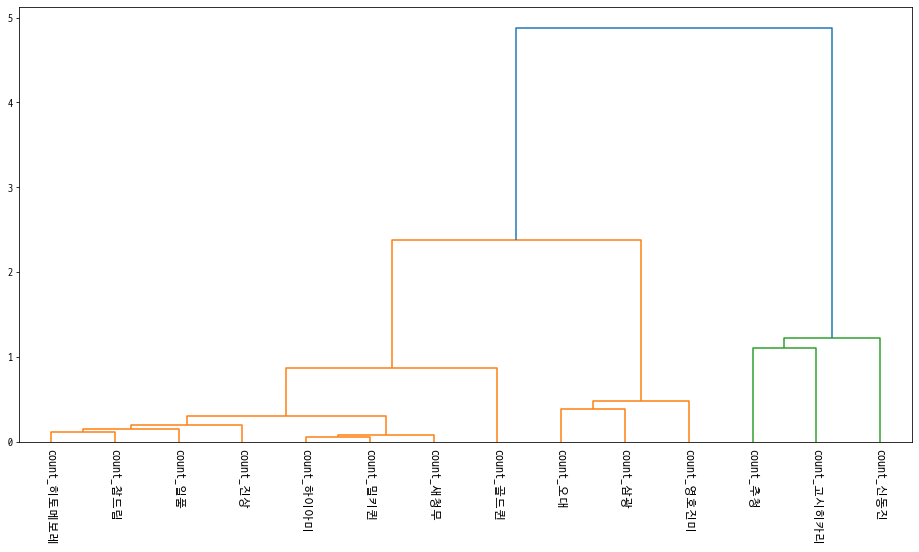

In [9]:
#02. 
#(1)
linked = linkage(cultivar_dataset, 'ward')
labelList = cultivar_dataset.index

#(2)
plt.figure(figsize=(16, 8))
dendrogram(linked,
            orientation='top',
            labels=labelList,
            distance_sort='descending',
            show_leaf_counts=True)
plt.xticks(rotation=-90)            
plt.show()

In [14]:
#(3)
cluster = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
cultivar_dataset['cluster_num'] = cluster.fit_predict(cultivar_dataset)

#(4)
cultivar_dataset

,고소하다,고슬하다,꼬들하다,달다,딱딱하다,부드럽다,질다,쫀득하다,찰지다,촉촉하다,탱탱하다,푸석하다,cluster_num
cultivar,,,,,,,,,,,,,
count_고시히카리,0.648148,1.000000,0.742857,0.965217,0.25000,0.629032,0.657143,1.000000,0.725000,0.927711,0.584746,0.408284,2
count_골드퀸,0.692593,0.020408,0.028571,0.104348,0.03125,0.016129,0.057143,0.041667,0.037500,0.036145,0.008475,0.023669,1
count_밀키퀸,0.003704,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005917,1
count_삼광,0.477778,0.571429,0.314286,0.547826,0.40625,0.387097,0.314286,0.468750,0.453125,0.313253,0.254237,0.366864,0
count_새청무,0.022222,0.020408,0.000000,0.008696,0.00000,0.000000,0.028571,0.020833,0.009375,0.048193,0.008475,0.011834,1
count_신동진,1.000000,0.734694,1.000000,1.000000,1.00000,0.661290,0.828571,0.802083,1.000000,1.000000,1.000000,0.840237,0
count_영호진미,0.237037,0.367347,0.314286,0.173913,0.46875,0.403226,0.342857,0.411458,0.396875,0.265060,0.144068,0.431953,0
count_오대,0.311111,0.326531,0.314286,0.443478,0.34375,0.209677,0.400000,0.447917,0.415625,0.337349,0.262712,0.431953,0
count_일품,0.085185,0.040816,0.085714,0.060870,0.03125,0.048387,0.057143,0.057292,0.081250,0.072289,0.008475,0.076923,1


In [15]:
#04. 군집 시각화하기. 
#(1) 주성분 분석을 통해 2차원으로 축소하기. 
pca = PCA(n_components=2, random_state=2021)
cultivar_dataset_pca = pca.fit_transform(cultivar_dataset.iloc[:, :-1])
cultivar_dataset_pca = pd.DataFrame(cultivar_dataset_pca, columns=['PC1','PC2'])
cultivar_dataset_pca['cluster_num'] = cluster.fit_predict(cultivar_dataset)
cultivar_dataset_pca.set_index(cultivar_dataset.index, inplace=True)
cultivar_dataset_pca

,PC1,PC2,cluster_num
cultivar,,,
count_고시히카리,1.581405,-0.465021,2
count_골드퀸,-0.619955,-0.078634,1
count_밀키퀸,-0.923990,-0.000146,1
count_삼광,0.484905,-0.059245,0
count_새청무,-0.874158,-0.019133,1
count_신동진,2.195319,-0.137444,0
count_영호진미,0.203592,0.195185,0
count_오대,0.304225,0.001134,0
count_일품,-0.720166,0.010817,1


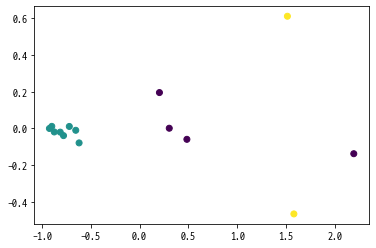

In [16]:
#(2) PCA 처리값을 기반으로 시각화하기. 
plt.scatter(x=cultivar_dataset_pca['PC1'], y=cultivar_dataset_pca['PC2'], c=cultivar_dataset_pca['cluster_num'])
plt.show()